# PCA

In [106]:
import numpy as np
import matplotlib.pyplot as plt

In [107]:
from sklearn.decomposition import PCA

X = [[2, 3], [3, 4], [7, 5], [8, 8]]

pca = PCA(n_components=1, svd_solver="full")
X_pca = pca.fit_transform(X)

print(X_pca)                       # Координаты студентов на новой оси
print(pca.explained_variance_ratio_)  # [0.9507...] — около 95,1%

[[-3.6042]
 [-2.2103]
 [ 1.6327]
 [ 4.1817]]
[0.9507]


In [108]:
BLUE, ORANGE, GRAY = "#2364AA", "#D55E00", "#737B84"
def draw_points(ax, data, title, color=BLUE, labels=True, label=None):
    data = np.asarray(data)
    ax.scatter(data[:, 0], data[:, 1],
               s=55, color=color, label=label, zorder=3)
    if labels:
        for i, (x, y) in enumerate(data, start=1):
            right_half = x > (data[:, 0].min() + data[:, 0].max()) / 2
            ax.annotate(f"Студент {i}", (x, y),
                        xytext=(-6 if right_half else 6, 7),
                        ha="right" if right_half else "left", textcoords="offset points",
                        fontsize=10)
    ax.axhline(0, color=GRAY, linewidth=0.7)
    ax.axvline(0, color=GRAY, linewidth=0.7)
    ax.set(title=title, xlabel="Python", ylabel="R")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2)


def square_limits(ax, rows, padding=0.7):
    rows = np.asarray(rows)
    low = min(0.0, rows.min()) - padding
    high = max(0.0, rows.max()) + padding
    ax.set(xlim=(low, high), ylim=(low, high))

In [109]:
DATA = np.array([[2, 3], [3, 4], [7, 5], [8, 8]], dtype=float)
np.set_printoptions(precision=4, suppress=True)
n = len(DATA)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

print("Студент |    Python |         R")
for i, (x, y) in enumerate(DATA, start=1):
    print(f"{i:6d} | {x:9.1f} | {y:9.1f}")

Студент |    Python |         R
     1 |       2.0 |       3.0
     2 |       3.0 |       4.0
     3 |       7.0 |       5.0
     4 |       8.0 |       8.0


## 1. Исходные данные

Строка — студент, столбцы — его оценки по Python и R.
Задача — заменить два признака одним индексом, сохранив максимум дисперсии.

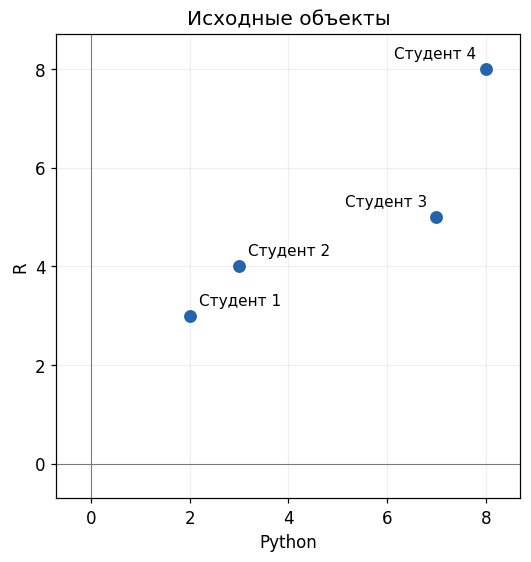

In [110]:
fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
draw_points(ax, DATA, "Исходные объекты")
square_limits(ax, DATA)
plt.show()

## 2. Центрируем данные

Как на странице 5, вычитаем среднее каждого предмета:
$\overline{\mathrm{Python}}=5$, $\overline{R}=5$.
Получаем пары $(-3,-2)$, $(-2,-1)$, $(2,0)$, $(3,3)$.

Облако сдвигается к началу координат, его форма сохраняется.
Следуем вычислениям презентации: выполняем центрирование без деления на стандартное отклонение.

In [111]:
means = DATA.mean(axis=0)
X = DATA - means

print("Средние исходных признаков:", means)
print("Центрированные данные:")
X

Средние исходных признаков: [5. 5.]
Центрированные данные:


array([[-3., -2.],
       [-2., -1.],
       [ 2.,  0.],
       [ 3.,  3.]])

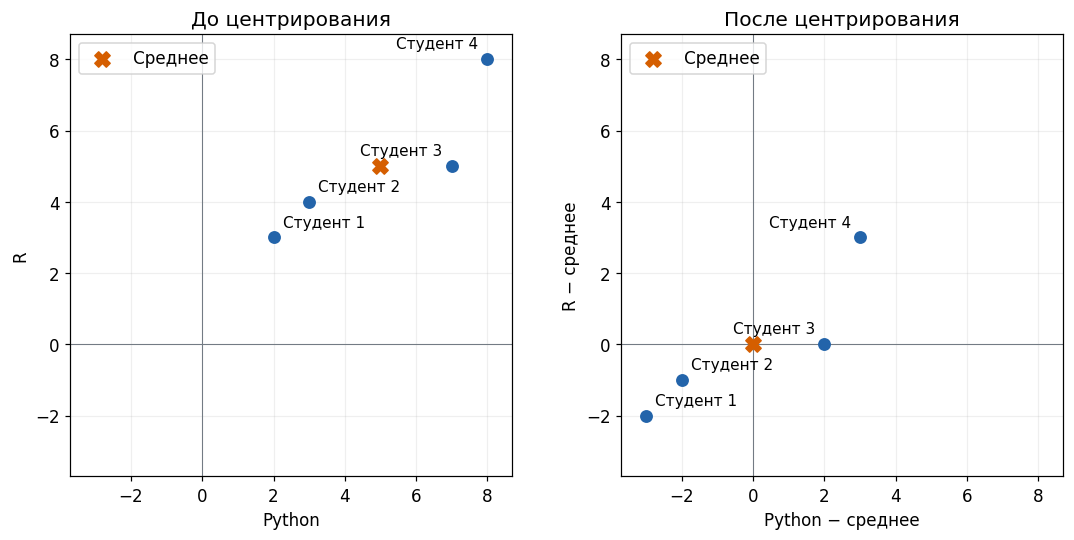

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), layout="constrained")
for ax, rows, title, mean in zip(
    axes, [DATA, X], ["До центрирования", "После центрирования"], [means, [0, 0]]
):
    draw_points(ax, rows, title)
    ax.scatter(*mean, marker="X", s=100, color=ORANGE, zorder=4, label="Среднее")
    if title == "После центрирования":
        ax.set(xlabel="Python − среднее", ylabel="R − среднее")
    square_limits(ax, np.vstack((DATA, X)))
    ax.legend(loc="upper left")
plt.show()

## 3. Считаем ковариационную матрицу

Строки $X$ — объекты, столбцы — признаки. Выборочная ковариационная матрица:

$$C=\frac{X^\mathsf{T}X}{n-1},\qquad
C_{ij}=\frac{1}{n-1}\sum_{k=1}^n X_{ki}X_{kj}.$$

In [113]:
C = X.T @ X / (n - 1)

print("Ковариационная матрица C:")
C

Ковариационная матрица C:


array([[8.6667, 5.6667],
       [5.6667, 4.6667]])

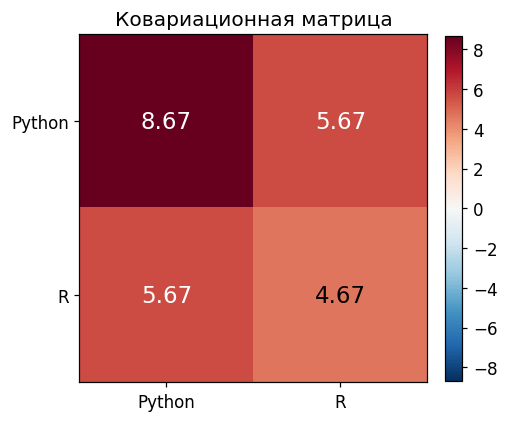

In [114]:
fig, ax = plt.subplots(figsize=(4.5, 4), layout="constrained")
color_limit = max(float(np.abs(C).max()), 1e-12)
heatmap = ax.imshow(C, cmap="RdBu_r", vmin=-color_limit, vmax=color_limit)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{C[i][j]:.2f}", ha="center", va="center", color="white" if abs(C[i][j]) > 0.6 * color_limit else "black", fontsize=15)
ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=["Python", "R"],
       yticklabels=["Python", "R"], title="Ковариационная матрица")
fig.colorbar(heatmap, ax=ax, shrink=0.8)
plt.show()


## 4. Находим главные направления

Решаем задачу на собственные значения симметричной ковариационной матрицы:

$$Cv_j=\lambda_jv_j.$$

`np.linalg.eigh(C)` возвращает собственные значения и единичные собственные векторы.
Упорядочим компоненты по убыванию дисперсии $\lambda_j$.


In [115]:
def component_signs(axes):
    """Одна ось в строке; знак её наибольшего по модулю коэффициента."""
    pivots = np.abs(axes).argmax(axis=1)
    return np.where(axes[np.arange(len(axes)), pivots] < 0, -1.0, 1.0)


eigenvalues, eigenvectors = np.linalg.eigh(C)
order = np.argsort(eigenvalues)[::-1]
values = np.maximum(eigenvalues[order], 0.0)
axes_pca = eigenvectors[:, order].T  # Одна главная ось в каждой строке.
axes_pca *= component_signs(axes_pca)[:, None]
v1, v2 = axes_pca
if values.sum() == 0:
    raise ValueError("Все точки совпадают: дисперсия равна нулю.")
ratios = values / values.sum()
for j, (value, axis, ratio) in enumerate(zip(values, axes_pca, ratios), start=1):
    print(f"PC{j}: направление ({axis[0]:.4f}, {axis[1]:.4f}), "
          f"дисперсия {value:.3f}, доля {ratio:.2%}")

PC1: направление (0.8163, 0.5776), дисперсия 12.676, доля 95.07%
PC2: направление (-0.5776, 0.8163), дисперсия 0.657, доля 4.93%


## 5. Выбираем одну компоненту и рисуем оси

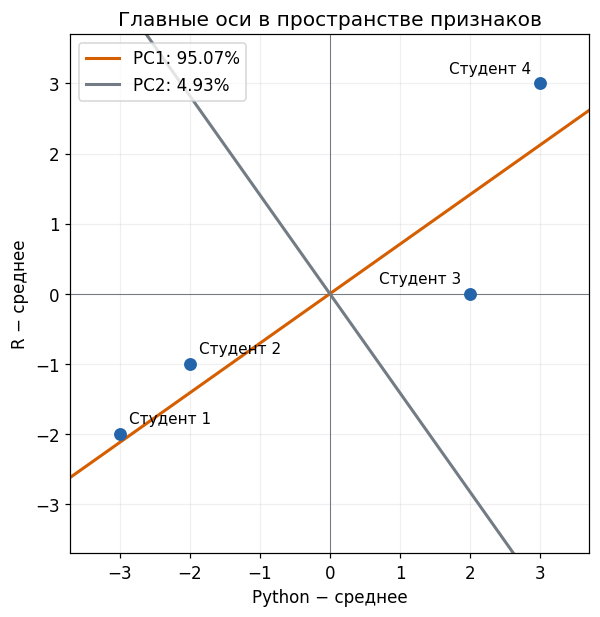

In [116]:
fig, ax = plt.subplots(figsize=(6, 5.5), layout="constrained")
draw_points(ax, X, "Главные оси в пространстве признаков")
ax.set(xlabel="Python − среднее", ylabel="R − среднее")
length = 1.2 * np.linalg.norm(X, axis=1).max()
for vector, color, name, ratio in zip(axes_pca, [ORANGE, GRAY], ["PC1", "PC2"], ratios):
    ax.plot([-length * vector[0], length * vector[0]],
            [-length * vector[1], length * vector[1]],
            color=color, linewidth=2, label=f"{name}: {ratio:.2%}")
square_limits(ax, X)
ax.legend(loc="upper left")
plt.show()


## 6. Проекция и индекс успеваемости

Скалярное произведение центрированных оценок с PC1 даёт индекс студента:

$$z_i = (\mathrm{Python}_i-5)\,v_{1,1}+(R_i-5)\,v_{1,2}.$$

Для нашего примера $v_1\approx(0{,}8163;\,0{,}5776)$.
Выбрали знак оси так, чтобы рост оценок повышал индекс. Это относительная координата
в данной выборке, а не оценка по исходной шкале.

В презентации коэффициенты округлены до $(0{,}82;\,0{,}58)$.
Поэтому полученные там значения $-3{,}62$, $-2{,}22$, $1{,}64$, $4{,}20$
немного отличаются от расчёта с полной точностью. Ниже покажем оба варианта.
Проекция обратно на линию PC1 в двумерном пространстве равна $\hat x_i=z_i v_1$.

Студент | PC1 (точный расчёт) |      PC2 | PC1 с v=(0.82, 0.58)
      1 |            -3.6042 |   0.1000 |               -3.62
      2 |            -2.2103 |   0.3388 |               -2.22
      3 |             1.6327 |  -1.1551 |                1.64
      4 |             4.1817 |   0.7163 |                4.20


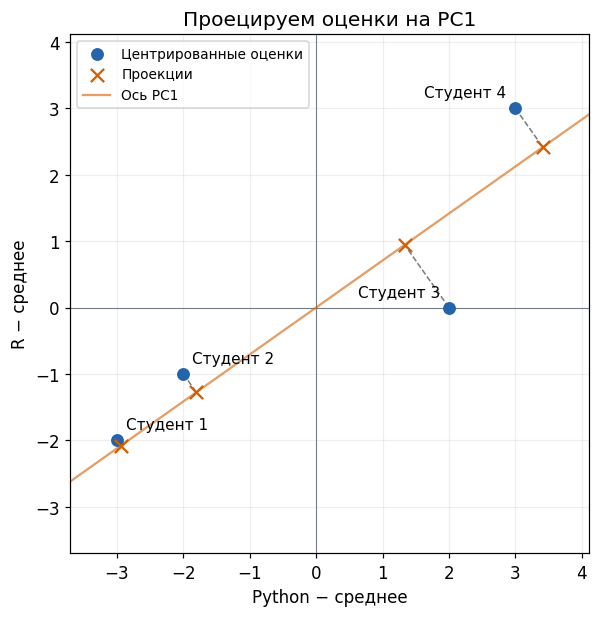

In [117]:
scores = X @ v1
scores_pc2 = X @ v2
projected = np.outer(scores, v1)
slide_scores = X @ np.array([0.82, 0.58])
print("Студент | PC1 (точный расчёт) |      PC2 | PC1 с v=(0.82, 0.58)")
for i, (score, score2, slide_score) in enumerate(zip(scores, scores_pc2, slide_scores), start=1):
    print(f"{i:7d} | {score:18.4f} | {score2:8.4f} | {slide_score:19.2f}")

fig, ax = plt.subplots(figsize=(6.5, 5.5), layout="constrained")
draw_points(ax, X, "Проецируем оценки на PC1", label="Центрированные оценки")
ax.set(xlabel="Python − среднее", ylabel="R − среднее")
for row, projection in zip(X, projected):
    ax.plot([row[0], projection[0]], [row[1], projection[1]],
            linestyle="--", color=GRAY, linewidth=1)
ax.scatter(projected[:, 0], projected[:, 1],
           color=ORANGE, s=75, marker="x", label="Проекции", zorder=4)
end = np.abs(scores).max() + 1
ax.plot([-end * v1[0], end * v1[0]], [-end * v1[1], end * v1[1]],
        color=ORANGE, alpha=0.6, label="Ось PC1")
square_limits(ax, np.vstack((X, projected)))
ax.legend(loc="upper left", fontsize=9)
plt.show()

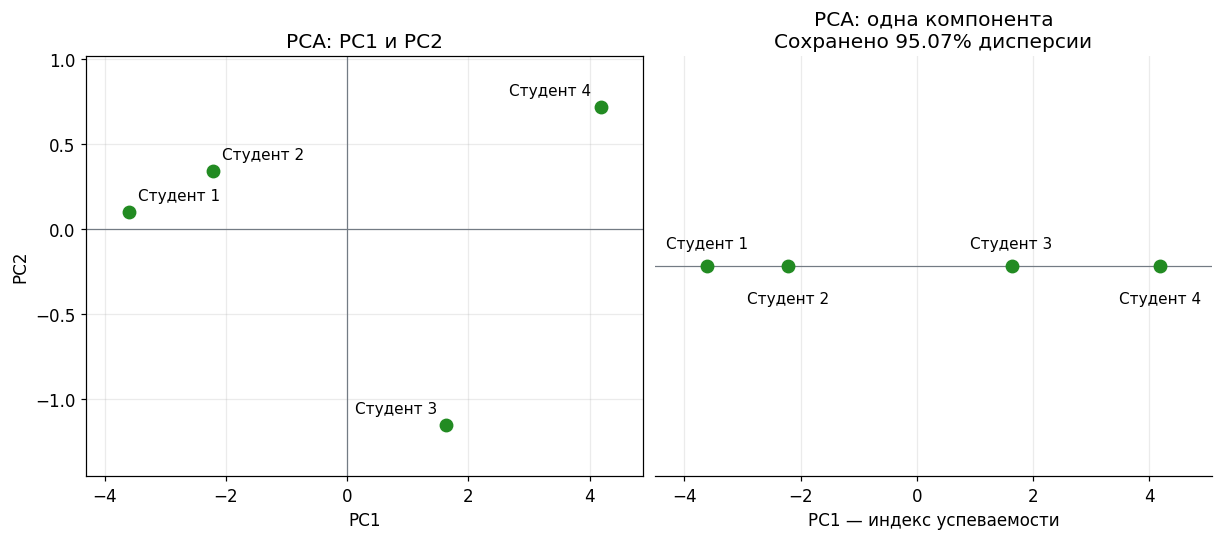

По убыванию индекса: студент 4 → студент 3 → студент 2 → студент 1


In [118]:
fig, (pc_ax, score_ax) = plt.subplots(1, 2, figsize=(11, 4.8), layout="constrained")
pc_ax.scatter(scores, scores_pc2, color="forestgreen", s=65, zorder=3)
pc_ax.axhline(0, color=GRAY, linewidth=0.8)
pc_ax.axvline(0, color=GRAY, linewidth=0.8)
pc_ax.set(title="PCA: PC1 и PC2", xlabel="PC1", ylabel="PC2",
          xlim=(min(scores) - 0.7, max(scores) + 0.7),
          ylim=(min(scores_pc2) - 0.3, max(scores_pc2) + 0.3))
for i, (x, y) in enumerate(zip(scores, scores_pc2), start=1):
    pc_ax.annotate(f"Студент {i}", (x, y),
                   xytext=(-6 if x > 0 else 6, 8), textcoords="offset points",
                   ha="right" if x > 0 else "left", fontsize=10)
pc_ax.grid(alpha=0.25)

score_ax.axhline(0, color=GRAY, linewidth=0.8)
score_ax.scatter(scores, np.zeros(n), color="forestgreen", s=65, zorder=3)
for i, coordinate in enumerate(scores, start=1):
    score_ax.annotate(f"Студент {i}", (coordinate, 0),
                      xytext=(0, 12 if i % 2 else -24), textcoords="offset points",
                      ha="center", fontsize=10)
score_ax.set(title=f"PCA: одна компонента\nСохранено {ratios[0]:.2%} дисперсии",
             xlabel="PC1 — индекс успеваемости", yticks=[], ylim=(-0.5, 0.5),
             xlim=(min(scores) - 0.9, max(scores) + 0.9))
score_ax.spines[["left", "right", "top"]].set_visible(False)
score_ax.grid(axis="x", alpha=0.25)
plt.show()

ranking = np.argsort(scores)[::-1].tolist()
print("По убыванию индекса: " + " → ".join(f"студент {i + 1}" for i in ranking))

## 7. Второй способ: SVD

Применим `np.linalg.svd` непосредственно к центрированной матрице $X$.
Ковариационную матрицу для этого вычислять не нужно.

Получаем $X=U\Sigma V^\mathsf{T}$. Столбцы $V$ — направления PCA,
$\sigma_j$ — сингулярные числа, а дисперсии компонент равны
$\lambda_j=\sigma_j^2/(n-1)$. Новые координаты объектов: $XV=U\Sigma$.

При изменении знака строки $V^\mathsf{T}$ меняем знак соответствующего столбца $U$,
чтобы равенство $X=U\Sigma V^\mathsf{T}$ сохранилось.


In [119]:
U_full, sigma, svd_axes = np.linalg.svd(X, full_matrices=False)
# NumPy возвращает Vᵀ: его строки уже имеют нужный нам формат осей.
svd_signs = component_signs(svd_axes)
svd_axes *= svd_signs[:, None]
U_full *= svd_signs[None, :]
svd_values = sigma ** 2 / (n - 1)

# Для сокращённого разложения и тепловых карт оставляем ненулевые компоненты.
active = np.flatnonzero(sigma > 1e-12 * sigma[0])
U = U_full[:, active]
print("Сингулярные числа:", np.round(sigma, 6))
print("Дисперсии σ²/(n−1):", np.round(svd_values, 6))
print("Направления (строки Vᵀ):")
print(np.round(svd_axes, 6))


Сингулярные числа: [6.1667 1.4044]
Дисперсии σ²/(n−1): [12.6759  0.6574]
Направления (строки Vᵀ):
[[ 0.8163  0.5776]
 [-0.5776  0.8163]]


### Из каких матриц состоит SVD

Покажем сокращённое разложение $X=U\Sigma V^\mathsf{T}$.
В $U$ — нормированные координаты студентов, в $\Sigma$ — масштабы компонент,
а строки $V^\mathsf{T}$ задают направления новых осей в пространстве оценок Python и R.
Все три тепловые карты используют одну цветовую шкалу.


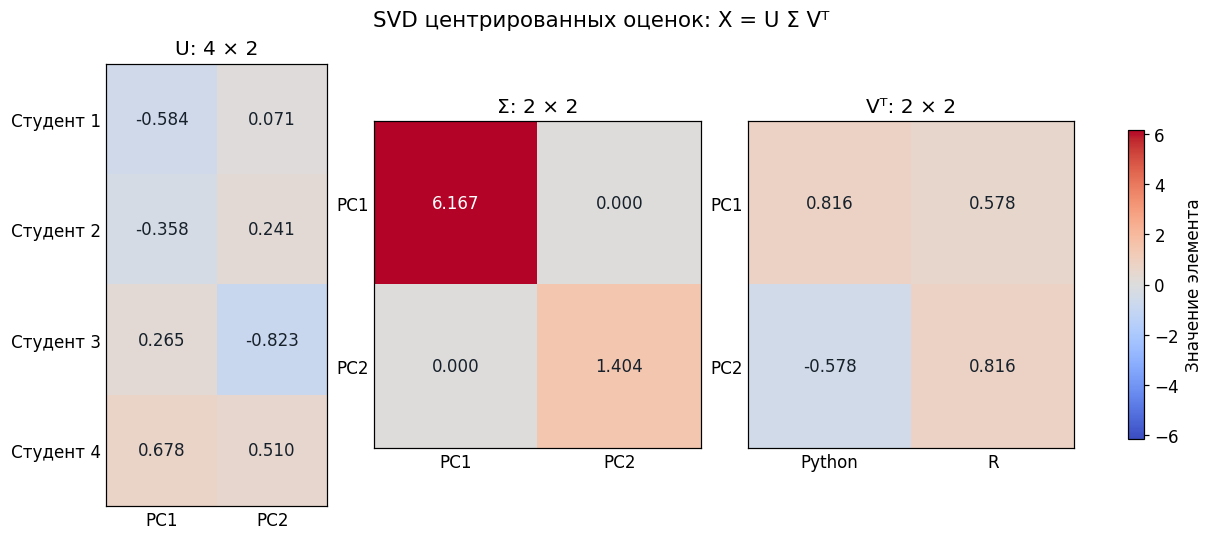

In [120]:
rank = len(active)
Sigma = np.diag(sigma[active])
V_transposed = svd_axes[active]
factors = [U, Sigma, V_transposed]
factor_titles = [f"U: {n} × {rank}", f"Σ: {rank} × {rank}", f"Vᵀ: {rank} × 2"]
component_labels = [f"PC{j + 1}" for j in active]

fig, factor_axes = plt.subplots(1, 3, figsize=(11, 4.8), layout="constrained")
fig.suptitle("SVD центрированных оценок: X = U Σ Vᵀ", fontsize=14)
if rank:
    color_limit = max(float(np.abs(U).max()), float(np.abs(Sigma).max()),
                      float(np.abs(V_transposed).max()))
    color_limit = max(color_limit, 1e-12)
    cmap = plt.get_cmap("coolwarm")
    for ax, matrix, title in zip(factor_axes, factors, factor_titles):
        heatmap = ax.imshow(matrix, cmap=cmap, vmin=-color_limit, vmax=color_limit)
        for i, row in enumerate(matrix):
            for j, value in enumerate(row):
                red, green, blue, _ = cmap((value + color_limit) / (2 * color_limit))
                brightness = 0.2126 * red + 0.7152 * green + 0.0722 * blue
                text_color = "white" if brightness < 0.45 else "#17212B"
                ax.text(j, i, f"{value:.3f}", ha="center", va="center", color=text_color)
        ax.set_title(title)
        ax.tick_params(length=0)
    factor_axes[0].set(xticks=range(rank), xticklabels=component_labels,
                       yticks=range(n), yticklabels=[f"Студент {i + 1}" for i in range(n)])
    factor_axes[1].set(xticks=range(rank), xticklabels=component_labels,
                       yticks=range(rank), yticklabels=component_labels)
    factor_axes[2].set(xticks=[0, 1], xticklabels=["Python", "R"],
                       yticks=range(rank), yticklabels=component_labels)
    fig.colorbar(heatmap, ax=list(factor_axes), shrink=0.7, label="Значение элемента")
else:
    # Все объекты одинаковы: центрированная матрица нулевая, ранг равен 0.
    for ax, title in zip(factor_axes, factor_titles):
        ax.set_title(title)
        ax.text(0.5, 0.5, "Нет ненулевых компонент", ha="center", va="center",
                transform=ax.transAxes, fontsize=10)
        ax.axis("off")
plt.show()


### Как SVD меняет координаты

Слева — центрированные оценки и оси из $V$.
Справа — те же студенты в новых координатах, вычисленных **непосредственно как $U\Sigma$**:
столбец $j$ матрицы $U$ умножаем на $\sigma_j$.
Пока сохраняем обе компоненты, меняется система координат, а расстояния между студентами сохраняются.


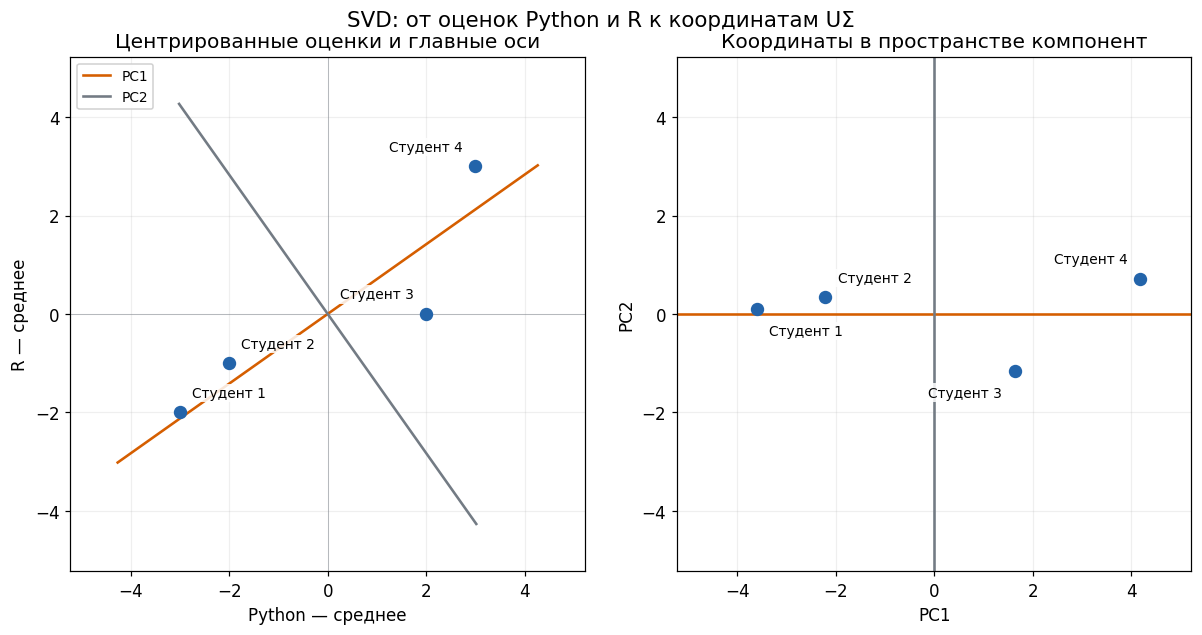

In [121]:
def plot_method_geometry(title, method_axes, coordinates):
    """X: глобальные данные n×2; method_axes: две оси; coordinates: n×r, r≤2.

    Показывает исходные центрированные данные и координаты в новых осях.
    Возвращает (fig, axes); вызывающая ячейка сама выполняет plt.show().
    """
    coordinates = np.asarray(coordinates)
    plotted_coordinates = np.pad(coordinates, ((0, 0), (0, 2 - coordinates.shape[1])))
    extent = np.abs(np.vstack((X, plotted_coordinates))).max()
    extent = max(1.0, extent * 1.25)
    fig, geometry_axes = plt.subplots(1, 2, figsize=(11, 5.6), layout="constrained")
    fig.suptitle(title, fontsize=14)

    for ax, rows, panel_title in zip(
        geometry_axes, [X, plotted_coordinates],
        ["Центрированные оценки и главные оси", "Координаты в пространстве компонент"]
    ):
        ax.scatter(rows[:, 0], rows[:, 1],
                   color=BLUE, s=60, zorder=4)
        # Совпадающие точки рисуем в истинных координатах и подписываем вместе.
        groups = {}
        for i, (x, y) in enumerate(rows, start=1):
            groups.setdefault((round(x, 10), round(y, 10)), []).append(i)
        for (x, y), student_ids in groups.items():
            label = ("Студент " if len(student_ids) == 1 else "Студенты ")
            label += ", ".join(map(str, student_ids))
            ax.annotate(label, (x, y), xytext=(-8 if x > 0 else 8, 10 if ax is geometry_axes[0] else (-17 if student_ids[0] % 2 else 10)),
                        ha="right" if x > 0 else "left", textcoords="offset points",
                        fontsize=9, zorder=5,
                        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 1.5})
        ax.set(title=panel_title, xlim=(-extent, extent), ylim=(-extent, extent))
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.2)

    left, right = geometry_axes
    left.axhline(0, color=GRAY, linewidth=0.6, alpha=0.5)
    left.axvline(0, color=GRAY, linewidth=0.6, alpha=0.5)
    for j, (vector, color) in enumerate(zip(method_axes, [ORANGE, GRAY]), start=1):
        left.plot([-extent * vector[0], extent * vector[0]],
                  [-extent * vector[1], extent * vector[1]],
                  color=color, linewidth=1.7, label=f"PC{j}", zorder=2)
    left.set(xlabel="Python — среднее", ylabel="R — среднее")
    left.legend(loc="upper left", fontsize=9, framealpha=0.9)
    right.axhline(0, color=ORANGE, linewidth=1.7, zorder=2)
    right.axvline(0, color=GRAY, linewidth=1.7, zorder=2)
    right.set(xlabel="PC1", ylabel="PC2")
    return fig, geometry_axes


# Масштабируем каждый столбец U соответствующим сингулярным числом.
svd_coordinates = np.zeros((n, 2))
svd_coordinates[:, active] = U * sigma[active]

fig, geometry_axes = plot_method_geometry(
    "SVD: от оценок Python и R к координатам UΣ", svd_axes, svd_coordinates
)
plt.show()


## 8. Третий способ: матрица Грама объектов

Строим $G=XX^\mathsf{T}$: для исходного примера это матрица $4\times4$.
Если $Gu=\mu u$, $\mu>0$ и $\lVert u\rVert=1$, то:

$$v=\frac{X^\mathsf{T}u}{\sqrt\mu},\qquad \lambda=\frac\mu{n-1}.$$

Собственные значения и векторы $G$ получаем через `np.linalg.eigh`.

В нашем маленьком примере $C$ меньше $G$. Способ через $G$ особенно удобен, когда **признаков больше, чем объектов**.


In [129]:
G = X @ X.T
mu, gram_eigenvectors = np.linalg.eigh(G)
gram_order = np.argsort(mu)[::-1]
mu = mu[gram_order]
gram_eigenvectors = gram_eigenvectors[:, gram_order]

# Убираем численный шум около нуля; ранг X не может быть больше двух.
gram_tolerance = 1e-12 * np.abs(mu).max()
gram_active = np.flatnonzero(mu > gram_tolerance)[:2]
positive_mu = mu[gram_active]
gram_U = gram_eigenvectors[:, gram_active]
root_mu = np.sqrt(positive_mu)

# Восстанавливаем направления в пространстве признаков: V = Xᵀ U / sqrt(μ).
recovered_axes = ((X.T @ gram_U) / root_mu).T
gram_signs = component_signs(recovered_axes)
recovered_axes *= gram_signs[:, None]
gram_U *= gram_signs[None, :]


In [130]:
gram_rank = len(gram_active)
gram_values = np.zeros(2)
gram_values[:gram_rank] = positive_mu / (n - 1)
gram_axes = np.eye(2)
gram_axes[:gram_rank] = recovered_axes
if gram_rank == 1:
    # При ранге 1 вторая ось перпендикулярна первой; её дисперсия нулевая.
    gram_axes[1] = [-gram_axes[0, 1], gram_axes[0, 0]]
    gram_axes[1:] *= component_signs(gram_axes[1:])[:, None]

print("Матрица Грама G:")
print(G)
print("Собственные значения G:", np.round(mu, 6))
print("Дисперсии μ/(n−1):", np.round(gram_values, 6))
print("Собственные векторы G:", np.round(gram_axes, 6))

Матрица Грама G:
[[ 13.   8.  -6. -15.]
 [  8.   5.  -4.  -9.]
 [ -6.  -4.   4.   6.]
 [-15.  -9.   6.  18.]]
Собственные значения G: [38.0278  1.9722  0.     -0.    ]
Дисперсии μ/(n−1): [12.6759  0.6574]
Собственные векторы G: [[ 0.8163  0.5776]
 [-0.5776  0.8163]]


### Что видно в матрице Грама

Слева — скалярные произведения центрированных оценок студентов.
Матрица имеет размер $4\times4$, хотя исходных признаков только два.
Справа — её собственные значения: ненулевых только два.
Их переводим в дисперсии главных компонент по формуле $\lambda_j=\mu_j/(n-1)$.

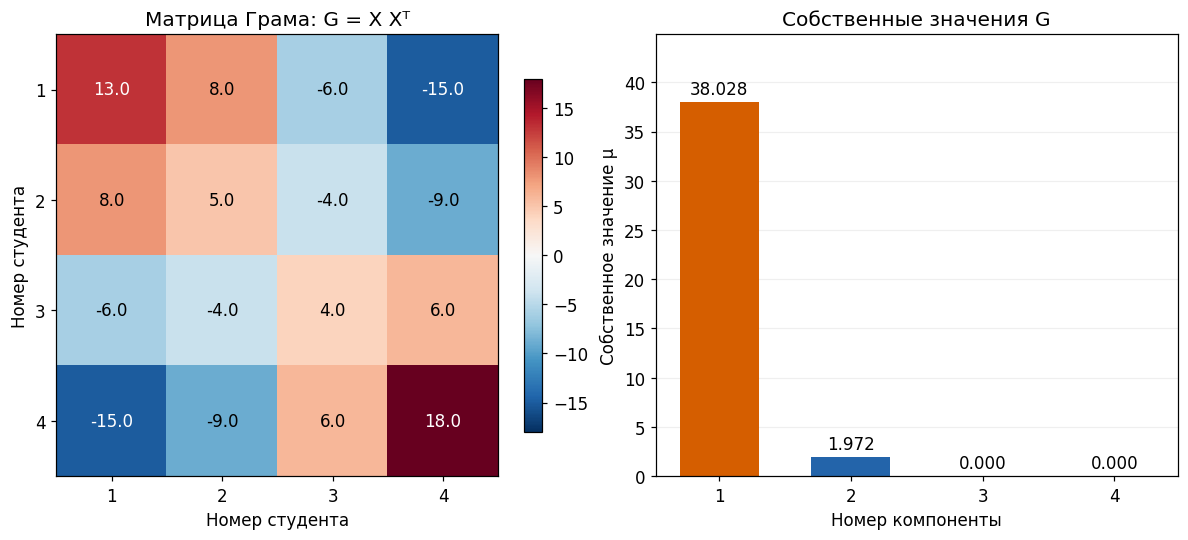

In [133]:
fig, (matrix_ax, spectrum_ax) = plt.subplots(1, 2, figsize=(11, 4.8), layout="constrained")
limit = max(float(np.abs(G).max()), 1e-12)
image = matrix_ax.imshow(G, cmap="RdBu_r", vmin=-limit, vmax=limit)
for i, row in enumerate(G):
    for j, value in enumerate(row):
        matrix_ax.text(j, i, f"{value:.1f}", ha="center", va="center",
                       color="white" if abs(value) > 0.6 * limit else "black")
matrix_ax.set(title="Матрица Грама: G = X Xᵀ",
              xlabel="Номер студента", ylabel="Номер студента",
              xticks=range(n), yticks=range(n),
              xticklabels=range(1, n + 1), yticklabels=range(1, n + 1))
fig.colorbar(image, ax=matrix_ax, shrink=0.8)

# Показываем численно нулевые собственные значения как нули.
mu_plot = np.where(np.abs(mu) <= gram_tolerance, 0.0, mu)
spectrum_ax.bar(range(1, n + 1), mu_plot,
                color=[ORANGE, BLUE] + [GRAY] * max(0, n - 2), width=0.6)
for index, value in enumerate(mu_plot, start=1):
    spectrum_ax.annotate(f"{value:.3f}", (index, value), xytext=(0, 5),
                         textcoords="offset points", ha="center")
spectrum_ax.set(title="Собственные значения G", xlabel="Номер компоненты",
                ylabel="Собственное значение μ", xticks=range(1, n + 1),
                ylim=(0, max(mu_plot) * 1.18))
spectrum_ax.grid(axis="y", alpha=0.2)
spectrum_ax.set_axisbelow(True)
plt.show()

### От собственных векторов Грама к графику студентов

Собственные векторы $G$ лежат в пространстве объектов: у каждого здесь четыре координаты.
Чтобы получить оси в пространстве двух предметов, используем
$v_j=X^\mathsf{T}u_j/\sqrt{\mu_j}$.

Координаты студентов можно получить напрямую: $Xv_j=\sqrt{\mu_j}\,u_j$.
Согласуем произвольные знаки векторов и построим эти координаты справа.
Слева — восстановленные оси на исходном центрированном облаке.

In [125]:
gram_coordinates = np.zeros((n, 2))
gram_coordinates[:, :gram_rank] = gram_U * root_mu

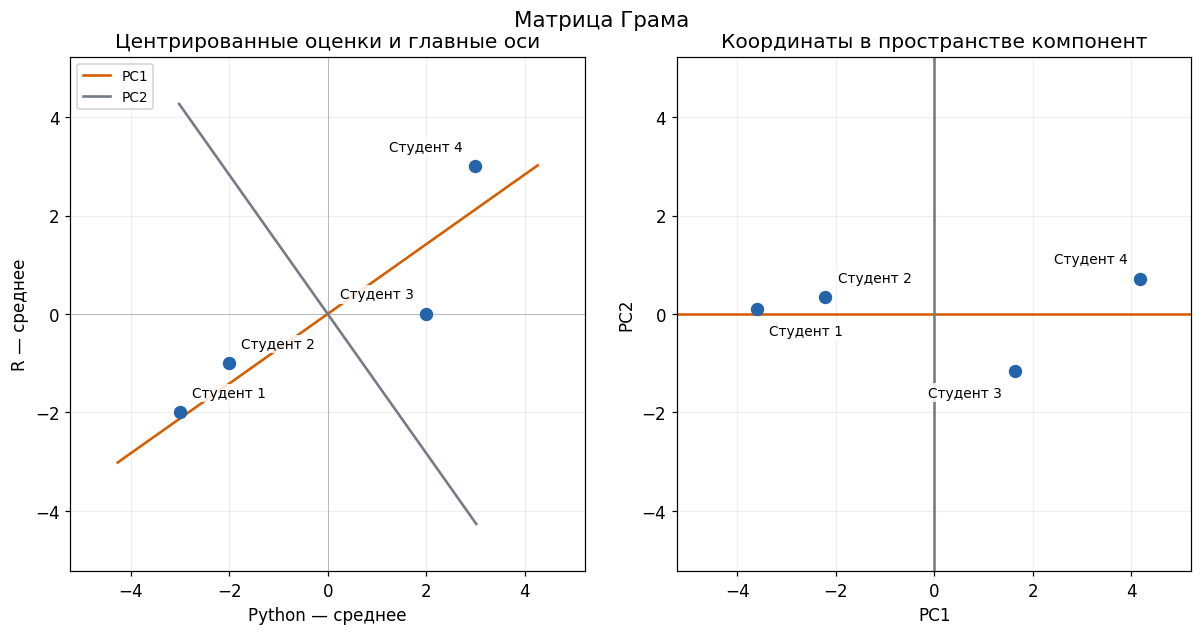

In [126]:
plot_method_geometry("Матрица Грама", gram_axes, gram_coordinates)
plt.show()
np.testing.assert_allclose(gram_coordinates, X @ gram_axes.T, atol=1e-9)

## 9. Sklearn

In [127]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, svd_solver="full")
sklearn_coordinates = pca.fit_transform(DATA)  # Форма результата: n студентов × 1 компоненту.

print("Средние, вычисленные sklearn:", pca.mean_)
print("Направление PC1:", pca.components_[0])
print("Направление PC2:", pca.components_[1])
print("Координаты студентов в новом базисе:")
print(sklearn_coordinates)
print(f"Объяснённая дисперсия: {pca.explained_variance_ratio_[0]:.2%}")

Средние, вычисленные sklearn: [5. 5.]
Направление PC1: [0.8163 0.5776]
Направление PC2: [-0.5776  0.8163]
Координаты студентов в новом базисе:
[[-3.6042  0.1   ]
 [-2.2103  0.3388]
 [ 1.6327 -1.1551]
 [ 4.1817  0.7163]]
Объяснённая дисперсия: 95.07%


## 10. Сравниваем 4 способа способа

In [128]:
results = {
    "Ковариация": (values, axes_pca),
    "SVD": (svd_values, svd_axes),
    "Матрица Грама": (gram_values, gram_axes),
    "Sklearn": (pca.explained_variance_, pca.components_)
}
print(f"{'Способ':16} {'λ₁':>8} {'λ₂':>8} {'Дисперсия PC1':>12}")
for name, (method_values, method_axes) in results.items():
    print(f"{name:16} {method_values[0]:8.4f} {method_values[1]:8.4f} "
          f"{method_values[0] / method_values.sum():12.2%} ")


Способ                 λ₁       λ₂ Дисперсия PC1
Ковариация        12.6759   0.6574       95.07% 
SVD               12.6759   0.6574       95.07% 
Матрица Грама     12.6759   0.6574       95.07% 
Sklearn           12.6759   0.6574       95.07% 
